# Assignment Part C
This notebook presents the modelling component of the COMP SCI 7209 Big Data Analysis and Project. The goal is to predict emergency department (ED) wait times using hospital staffing, temporal, and regional features. This work builds upon prior exploratory analysis (Part B) and contributes to identifying actionable insights for reducing patient delays in healthcare facilities.


In [1]:
# Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error, r2_score

In [2]:
# Loading the Dataset
file_path = "/content/drive/MyDrive/ER Wait Time Dataset.csv"
er_data = pd.read_csv(file_path)
er_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 19 columns):
 #   Column                              Non-Null Count  Dtype 
---  ------                              --------------  ----- 
 0   Visit ID                            5000 non-null   object
 1   Patient ID                          5000 non-null   object
 2   Hospital ID                         5000 non-null   object
 3   Hospital Name                       5000 non-null   object
 4   Region                              5000 non-null   object
 5   Visit Date                          5000 non-null   object
 6   Day of Week                         5000 non-null   object
 7   Season                              5000 non-null   object
 8   Time of Day                         5000 non-null   object
 9   Urgency Level                       5000 non-null   object
 10  Nurse-to-Patient Ratio              5000 non-null   int64 
 11  Specialist Availability             5000 non-null   int6

In [3]:
# First five rows of the dataset
er_data.head()

,Visit ID,Patient ID,Hospital ID,Hospital Name,Region,Visit Date,Day of Week,Season,Time of Day,Urgency Level,Nurse-to-Patient Ratio,Specialist Availability,Facility Size (Beds),Time to Registration (min),Time to Triage (min),Time to Medical Professional (min),Total Wait Time (min),Patient Outcome,Patient Satisfaction
0,HOSP-1-20240210-0001,PAT-00001,HOSP-1,Springfield General Hospital,Urban,2024-02-10 20:20:56,Saturday,Winter,Late Morning,Medium,4,3,92,17,22,66,105,Discharged,1
1,HOSP-3-20241128-0001,PAT-00002,HOSP-3,Northside Community Hospital,Rural,2024-11-28 02:07:47,Thursday,Fall,Evening,Medium,4,0,38,9,30,30,69,Discharged,3
2,HOSP-3-20240930-0002,PAT-00003,HOSP-3,Northside Community Hospital,Rural,2024-09-30 04:02:28,Monday,Fall,Evening,Low,5,1,38,38,40,125,203,Discharged,1
3,HOSP-2-20240227-0001,PAT-00004,HOSP-2,Riverside Medical Center,Urban,2024-02-27 00:31:13,Tuesday,Winter,Evening,High,4,5,94,8,16,64,88,Discharged,2
4,HOSP-1-20240306-0002,PAT-00005,HOSP-1,Springfield General Hospital,Urban,2024-03-06 16:52:26,Wednesday,Spring,Afternoon,Low,4,8,74,26,29,63,118,Discharged,1


In [4]:
# Last five rows of the data
er_data.tail()

,Visit ID,Patient ID,Hospital ID,Hospital Name,Region,Visit Date,Day of Week,Season,Time of Day,Urgency Level,Nurse-to-Patient Ratio,Specialist Availability,Facility Size (Beds),Time to Registration (min),Time to Triage (min),Time to Medical Professional (min),Total Wait Time (min),Patient Outcome,Patient Satisfaction
4995,HOSP-5-20241212-0989,PAT-04996,HOSP-5,Summit Health Center,Urban,2024-12-12 04:29:36,Thursday,Winter,Evening,Critical,2,1,142,6,10,19,35,Discharged,3
4996,HOSP-4-20240630-0995,PAT-04997,HOSP-4,St. Mary’s Regional Health,Rural,2024-06-30 22:44:17,Sunday,Summer,Evening,Medium,4,0,19,7,23,40,70,Discharged,3
4997,HOSP-2-20240213-1022,PAT-04998,HOSP-2,Riverside Medical Center,Urban,2024-02-13 21:06:17,Tuesday,Winter,Afternoon,Medium,3,7,163,14,29,87,130,Discharged,1
4998,HOSP-2-20240828-1023,PAT-04999,HOSP-2,Riverside Medical Center,Urban,2024-08-28 03:11:51,Wednesday,Summer,Afternoon,Low,5,4,160,21,35,73,129,Left Without Being Seen,1
4999,HOSP-1-20240825-0994,PAT-05000,HOSP-1,Springfield General Hospital,Urban,2024-08-25 23:05:40,Sunday,Summer,Evening,Medium,4,6,176,20,22,77,119,Discharged,1


In [5]:
# Checking for null values
er_data.isnull().sum()

,0
Visit ID,0
Patient ID,0
Hospital ID,0
Hospital Name,0
Region,0
Visit Date,0
Day of Week,0
Season,0
Time of Day,0
Urgency Level,0


In [6]:
# Renaming to lowercase and space to '_' for easy usecase
er_data.columns = (
        er_data.columns.str.strip()       # Removing leading/trailing whitespace
                       .str.lower()       # Converting to lowercase
                       .str.replace(' ', '_')
    )

er_data.columns

Index(['visit_id', 'patient_id', 'hospital_id', 'hospital_name', 'region',
       'visit_date', 'day_of_week', 'season', 'time_of_day', 'urgency_level',
       'nurse-to-patient_ratio', 'specialist_availability',
       'facility_size_(beds)', 'time_to_registration_(min)',
       'time_to_triage_(min)', 'time_to_medical_professional_(min)',
       'total_wait_time_(min)', 'patient_outcome', 'patient_satisfaction'],
      dtype='object')

In [7]:
# Checking for typo error in names of hospital
er_data['hospital_name'].unique()

array(['Springfield General Hospital', 'Northside Community Hospital',
       'Riverside Medical Center', 'Summit Health Center',
       'St. Mary’s Regional Health'], dtype=object)

In [8]:
er_data.describe()

,nurse-to-patient_ratio,specialist_availability,facility_size_(beds),time_to_registration_(min),time_to_triage_(min),time_to_medical_professional_(min),total_wait_time_(min),patient_satisfaction
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,3.238200,3.875000,87.118800,11.704200,24.827000,45.385400,81.916600,2.771600
std,1.200895,3.043292,57.998585,10.437284,24.807994,35.619975,68.084538,1.424584
min,1.000000,0.000000,10.000000,0.000000,1.000000,2.000000,4.000000,1.000000
25%,3.000000,1.000000,36.000000,3.000000,6.000000,17.000000,27.000000,1.000000
50%,3.000000,3.000000,74.000000,8.000000,16.000000,35.000000,60.000000,3.000000
75%,4.000000,6.000000,138.000000,18.000000,36.000000,66.000000,122.000000,4.000000
max,5.000000,10.000000,200.000000,66.000000,163.000000,233.000000,442.000000,5.000000


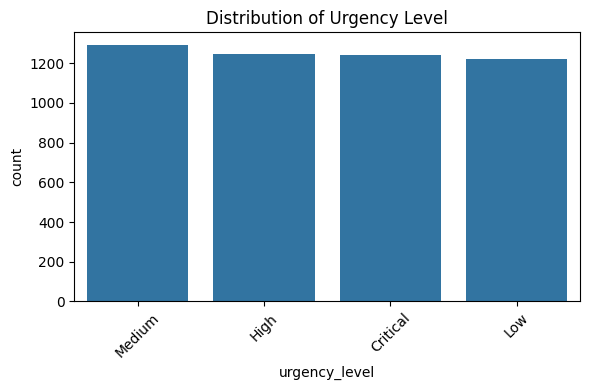

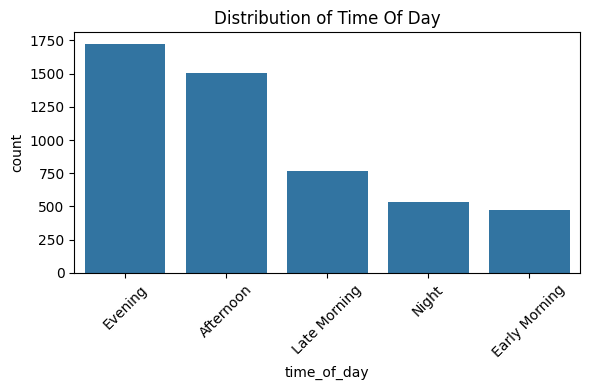

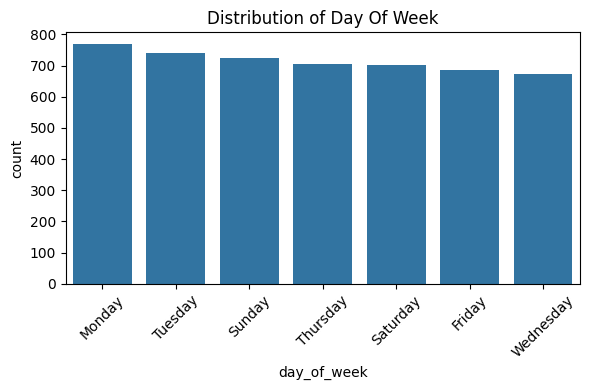

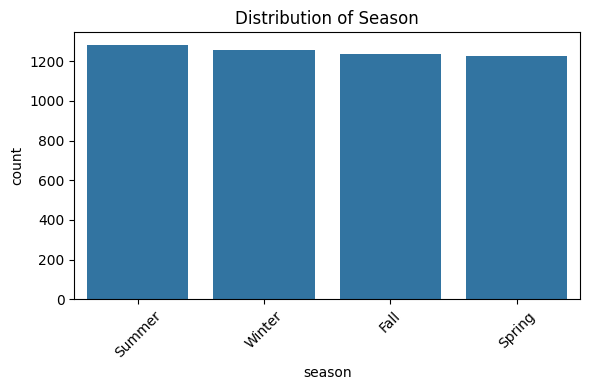

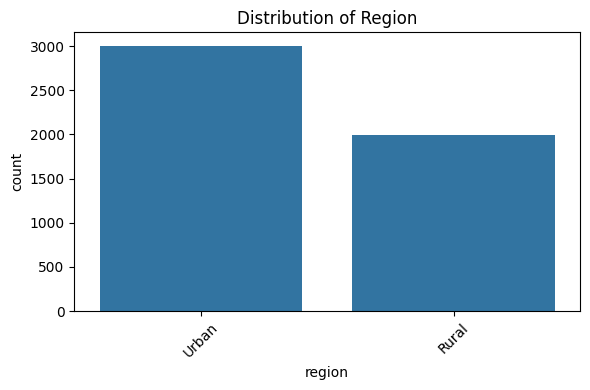

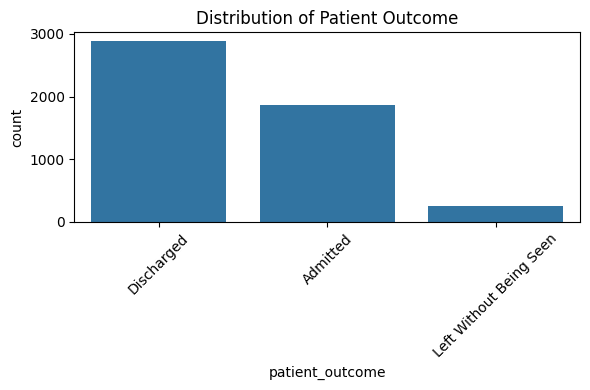

In [9]:
categorical_cols = ['urgency_level', 'time_of_day', 'day_of_week', 'season', 'region', 'patient_outcome']
for col in categorical_cols:
    plt.figure(figsize=(6, 4))
    sns.countplot(data=er_data, x=col, order=er_data[col].value_counts().index)
    plt.title(f'Distribution of {col.replace("_", " ").title()}')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

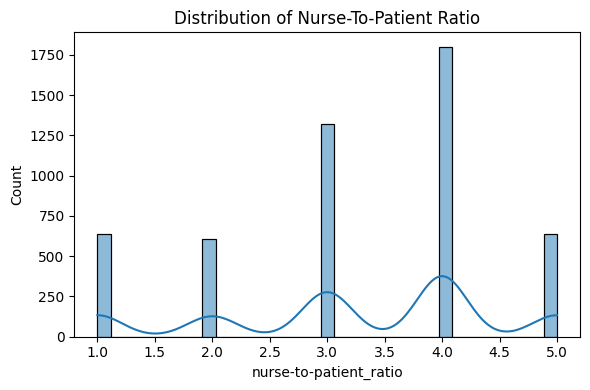

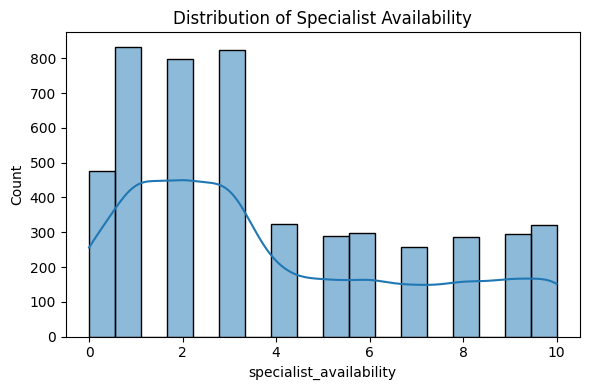

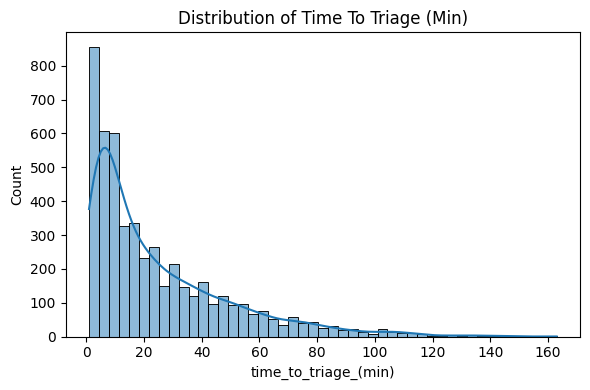

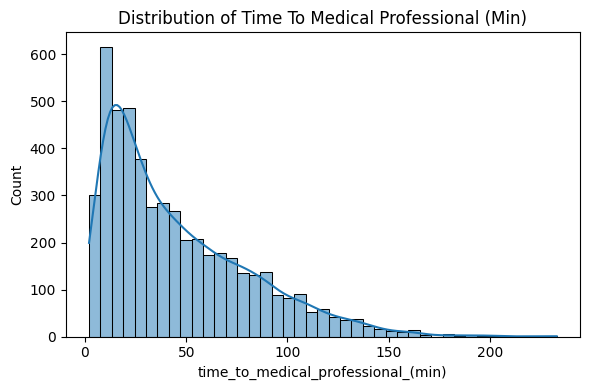

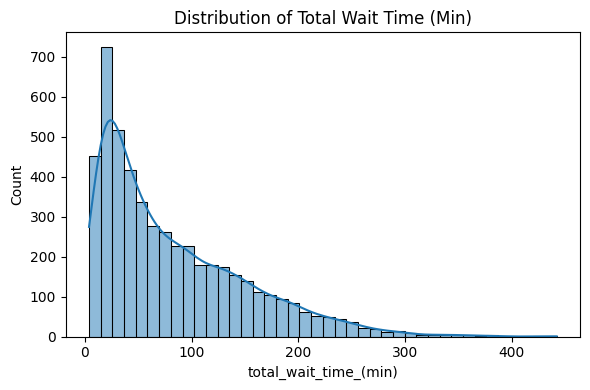

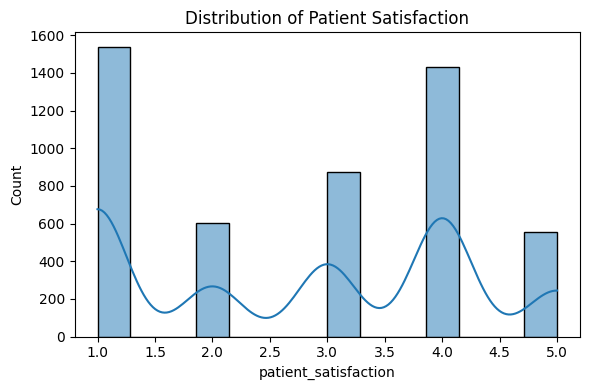

In [10]:
numerical_cols = ['nurse-to-patient_ratio', 'specialist_availability', 'time_to_triage_(min)',
                  'time_to_medical_professional_(min)', 'total_wait_time_(min)', 'patient_satisfaction']

for col in numerical_cols:
    plt.figure(figsize=(6, 4))
    sns.histplot(data = er_data, x=col, kde=True)
    plt.title(f'Distribution of {col.replace("_", " ").title()}')
    plt.tight_layout()
    plt.show()

In [11]:
# Feature Engineering
er_data['visit_date'] = pd.to_datetime(er_data['visit_date'])
er_data['hour'] = er_data['visit_date'].dt.hour
er_data['day_of_week'] = er_data['visit_date'].dt.day_name()
er_data['month'] = er_data['visit_date'].dt.month

for col in categorical_cols:
    le = LabelEncoder()
    er_data[col + '_encoded'] = le.fit_transform(er_data[col])

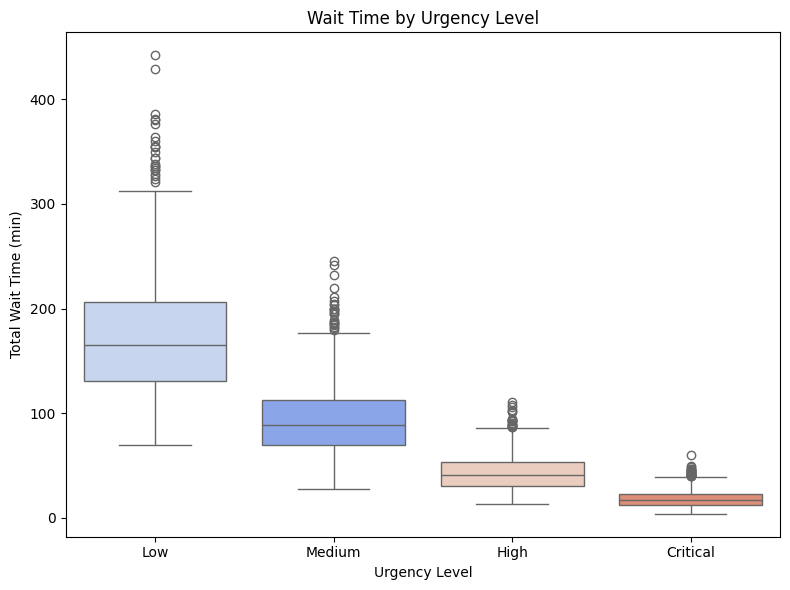

In [12]:
# Boxplot - Wait Time by Urgency Level
urgency_order = ['Low', 'Medium', 'High', 'Critical']
plt.figure(figsize=(8, 6))
sns.boxplot(data=er_data, x='urgency_level', y='total_wait_time_(min)',
            hue='urgency_level', palette='coolwarm',
            legend=False, order = urgency_order)
plt.title('Wait Time by Urgency Level')
plt.ylabel('Total Wait Time (min)')
plt.xlabel('Urgency Level')
plt.tight_layout()
plt.show()

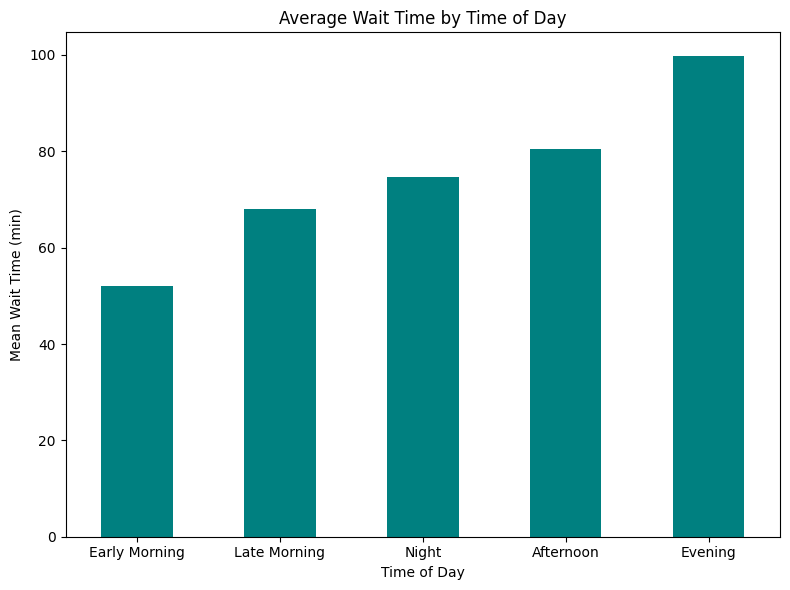

In [13]:
 # Bar Chart - Average Wait Time by Time of Day
plt.figure(figsize=(8, 6))
avg_by_time = er_data.groupby('time_of_day')['total_wait_time_(min)'].mean().sort_values()
avg_by_time.plot(kind='bar', color='teal')
plt.title('Average Wait Time by Time of Day')
plt.ylabel('Mean Wait Time (min)')
plt.xlabel('Time of Day')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

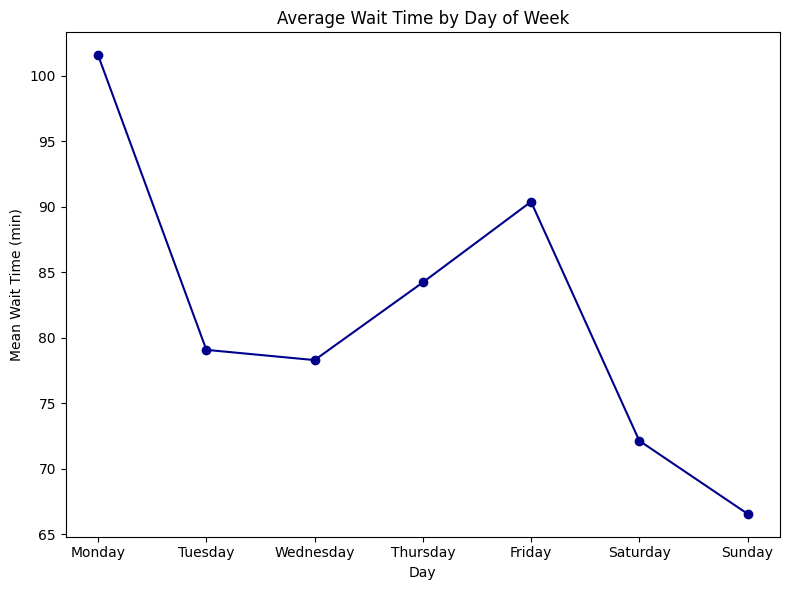

In [14]:
# Line Chart - Wait Time by Day of Week
plt.figure(figsize=(8, 6))
dow_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday',
             'Sunday']
avg_by_day = er_data.groupby('day_of_week')['total_wait_time_(min)'].mean().reindex(dow_order)
avg_by_day.plot(marker='o', color='darkblue')
plt.title('Average Wait Time by Day of Week')
plt.ylabel('Mean Wait Time (min)')
plt.xlabel('Day')
plt.tight_layout()
plt.show()

<Figure size 1000x600 with 0 Axes>

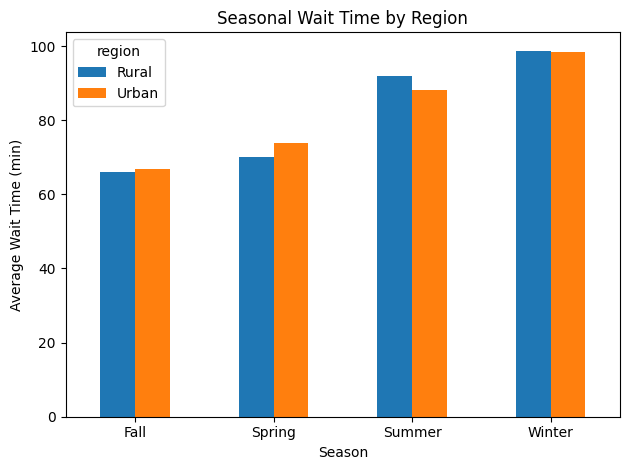

In [15]:
# Grouped Bar - Seasonal Wait Time by Region
plt.figure(figsize=(10, 6))
season_region = er_data.groupby(['season', 'region'])['total_wait_time_(min)'].mean().unstack()
season_region.plot(kind='bar')
plt.title('Seasonal Wait Time by Region')
plt.ylabel('Average Wait Time (min)')
plt.xlabel('Season')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

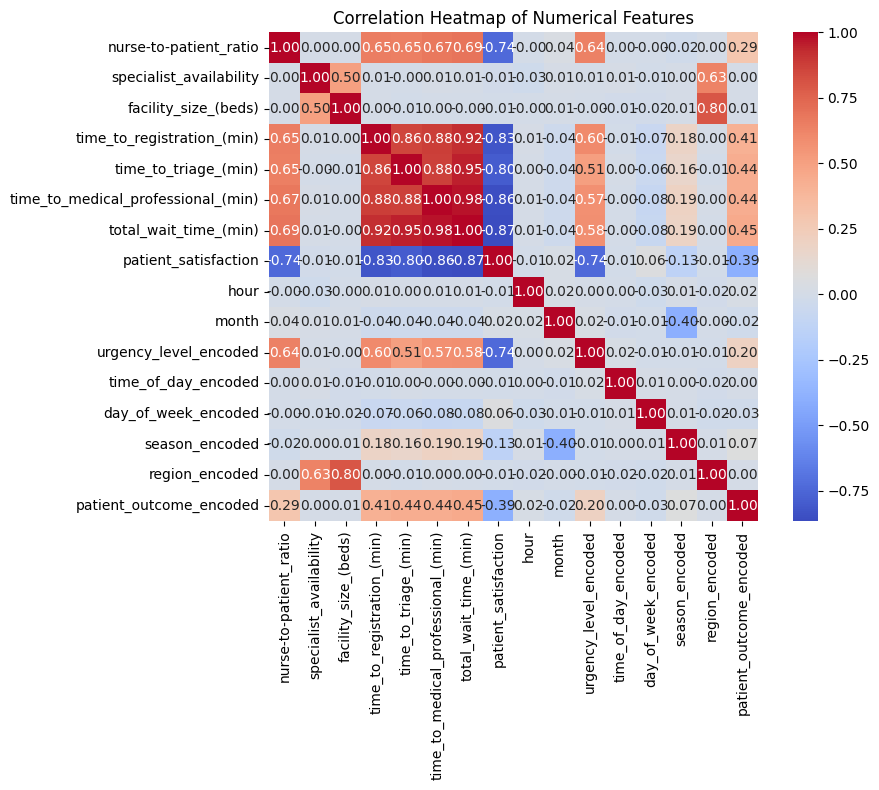

In [16]:
# Correlation Heatmap
plt.figure(figsize=(10, 8))
num_corr = er_data.select_dtypes(include='number').corr()
sns.heatmap(num_corr, annot=True, cmap='coolwarm', fmt=".2f", square=True)
plt.title('Correlation Heatmap of Numerical Features')
plt.tight_layout()
plt.show()

<Axes: xlabel='nurse-to-patient_ratio', ylabel='total_wait_time_(min)'>

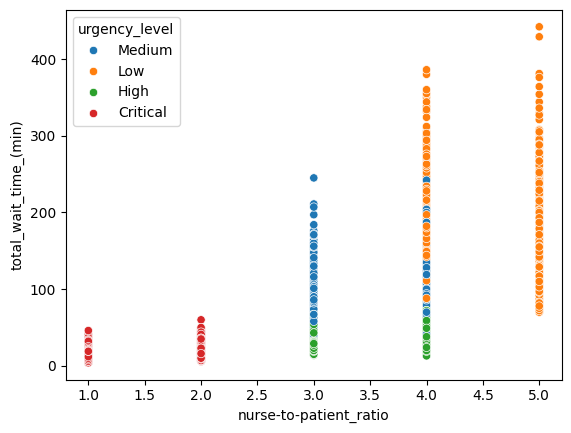

In [17]:
sns.scatterplot(data=er_data, x='nurse-to-patient_ratio', y='total_wait_time_(min)', hue='urgency_level')


In [18]:
er_data.head()

,visit_id,patient_id,hospital_id,hospital_name,region,visit_date,day_of_week,season,time_of_day,urgency_level,...,patient_outcome,patient_satisfaction,hour,month,urgency_level_encoded,time_of_day_encoded,day_of_week_encoded,season_encoded,region_encoded,patient_outcome_encoded
0,HOSP-1-20240210-0001,PAT-00001,HOSP-1,Springfield General Hospital,Urban,2024-02-10 20:20:56,Saturday,Winter,Late Morning,Medium,...,Discharged,1,20,2,3,3,2,3,1,1
1,HOSP-3-20241128-0001,PAT-00002,HOSP-3,Northside Community Hospital,Rural,2024-11-28 02:07:47,Thursday,Fall,Evening,Medium,...,Discharged,3,2,11,3,2,4,0,0,1
2,HOSP-3-20240930-0002,PAT-00003,HOSP-3,Northside Community Hospital,Rural,2024-09-30 04:02:28,Monday,Fall,Evening,Low,...,Discharged,1,4,9,2,2,1,0,0,1
3,HOSP-2-20240227-0001,PAT-00004,HOSP-2,Riverside Medical Center,Urban,2024-02-27 00:31:13,Tuesday,Winter,Evening,High,...,Discharged,2,0,2,1,2,5,3,1,1
4,HOSP-1-20240306-0002,PAT-00005,HOSP-1,Springfield General Hospital,Urban,2024-03-06 16:52:26,Wednesday,Spring,Afternoon,Low,...,Discharged,1,16,3,2,0,6,1,1,1


In [19]:
# Feature sets
numerical_features = ['nurse-to-patient_ratio', 'specialist_availability', 'hour', 'month']
categorical_features = ['urgency_level', 'time_of_day', 'day_of_week', 'season', 'region']
target = 'total_wait_time_(min)'

X = er_data[numerical_features + categorical_features]
y = er_data[target]


In [20]:
# Preprocessing pipeline
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numerical_features),
    ('cat', OneHotEncoder(drop='first'), categorical_features)
])

# Model pipelines
linear_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

random_forest_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', RandomForestRegressor(n_estimators=100, random_state=42))
])


In [21]:
# Splitting data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [22]:
# Training and evaluating Linear Regression
linear_model.fit(X_train, y_train)
y_pred_lr = linear_model.predict(X_test)
rmse_lr = root_mean_squared_error(y_test, y_pred_lr)
r2_lr = r2_score(y_test, y_pred_lr)

# Training and evaluating Random Forest
random_forest_model.fit(X_train, y_train)
y_pred_rf = random_forest_model.predict(X_test)
rmse_rf = root_mean_squared_error(y_test, y_pred_rf)
r2_rf = r2_score(y_test, y_pred_rf)

In [23]:
# Displaying results
print("Model Performance Summary:")
print(f"Linear Regression - RMSE: {rmse_lr:.2f}, R²: {r2_lr:.4f}")
print(f"Random Forest     - RMSE: {rmse_rf:.2f}, R²: {r2_rf:.4f}")

Model Performance Summary:
Linear Regression - RMSE: 24.75, R²: 0.8683
Random Forest     - RMSE: 18.78, R²: 0.9242


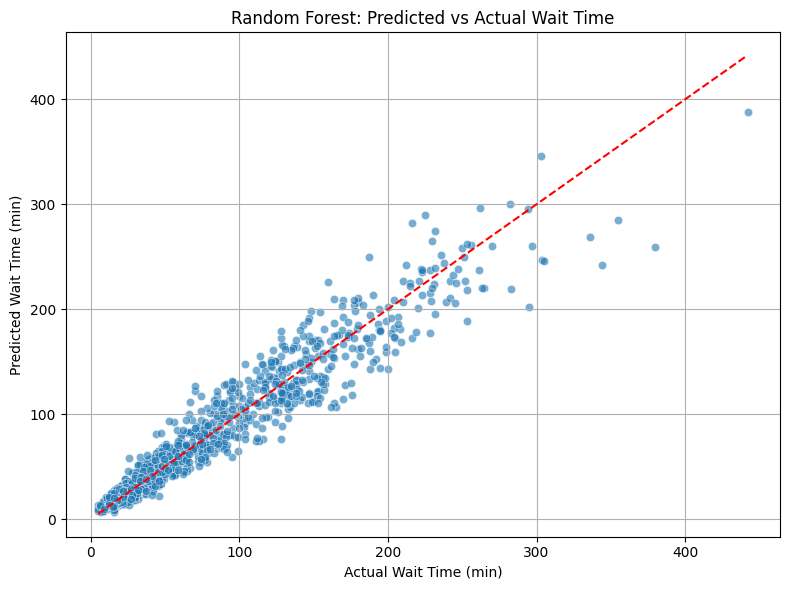

In [24]:
# Visualising predictions vs actual
best_preds = y_pred_lr if r2_lr > r2_rf else y_pred_rf
best_model_name = "Linear Regression" if r2_lr > r2_rf else "Random Forest"

plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=best_preds, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title(f'{best_model_name}: Predicted vs Actual Wait Time')
plt.xlabel('Actual Wait Time (min)')
plt.ylabel('Predicted Wait Time (min)')
plt.grid(True)
plt.tight_layout()
plt.show()

In [25]:
# Hyperparameter tuning using GridSearchCV for Random Forest
param_grid = {
    'regressor__n_estimators': [50, 100, 150],
    'regressor__max_depth': [None, 10, 20],
    'regressor__min_samples_split': [2, 5, 10]
}

tuned_rf = GridSearchCV(
    estimator=random_forest_model,
    param_grid=param_grid,
    cv=5,
    scoring='neg_mean_squared_error',
    n_jobs=-1
)

# Training tuned Random Forest
tuned_rf.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         StandardScaler(),
                                                                         ['nurse-to-patient_ratio',
                                                                          'specialist_availability',
                                                                          'hour',
                                                                          'month']),
                                                                        ('cat',
                                                                         OneHotEncoder(drop='first'),
                                                                         ['urgency_level',
                                                                          'time_of_day',
                                                                          'day_of_week',
                                                                          'season',
                                                                          'region'])])),
                                       ('regressor',
                                        RandomForestRegressor(random_state=42))]),
             n_jobs=-1,
             param_grid={'regressor__max_depth': [None, 10, 20],
                         'regressor__min_samples_split': [2, 5, 10],
                         'regressor__n_estimators': [50, 100, 150]},
             scoring='neg_mean_squared_error')

Best Random Forest Parameters: {'regressor__max_depth': 10, 'regressor__min_samples_split': 10, 'regressor__n_estimators': 150}
Tuned Random Forest - RMSE: 18.37, R²: 0.9274


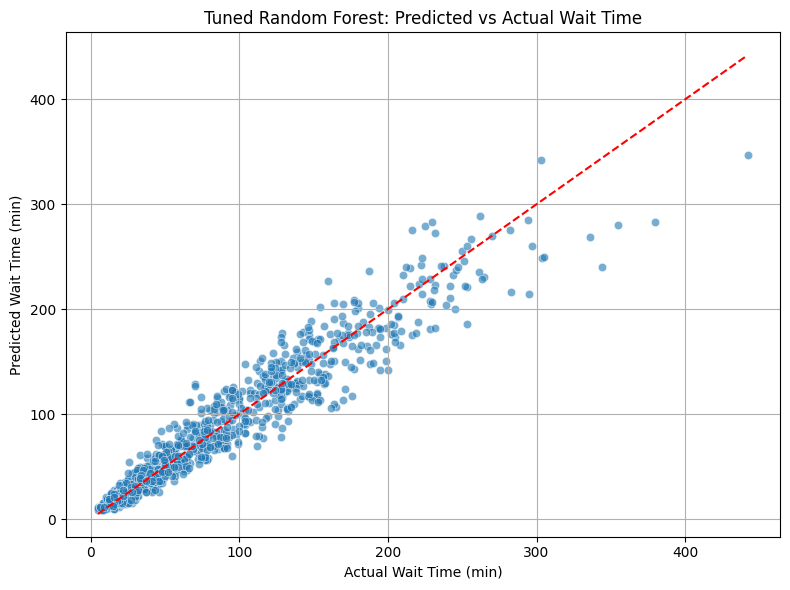

In [27]:
# Evaluating best model
best_rf_model = tuned_rf.best_estimator_
best_y_pred_rf = best_rf_model.predict(X_test)
best_rmse_rf = root_mean_squared_error(y_test, best_y_pred_rf)
best_r2_rf = r2_score(y_test, best_y_pred_rf)

print("Best Random Forest Parameters:", tuned_rf.best_params_)
print(f"Tuned Random Forest - RMSE: {best_rmse_rf:.2f}, R²: {best_r2_rf:.4f}")

# Comparing best model visually
best_preds = y_pred_rf if r2_rf > best_r2_rf else best_y_pred_rf
best_model_name = "Random Forest Before Tuning" if r2_lr > best_r2_rf else "Tuned Random Forest"

plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=best_preds, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title(f'{best_model_name}: Predicted vs Actual Wait Time')
plt.xlabel('Actual Wait Time (min)')
plt.ylabel('Predicted Wait Time (min)')
plt.grid(True)
plt.tight_layout()
plt.show()

### Interpretation of Final Model performance

The performance evaluation based on RMSE and R² metrics which indicates limited predictive power from the current feature set on the synthetic dataset. The best model (Random Forest) yielded:

- **RMSE:** 18.37
- **R²:** 0.9274

These results indicate the model explains little to no variance in ED wait time. This may be due to:
- Noise and simplifications in the simulated dataset
- Missing important features (e.g. age, triage category, patient load at time of arrival)